In [28]:
import os
import time
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

os.makedirs("data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [29]:
pantry = pd.read_csv("data/pantry.csv")
consumption = pd.read_csv("data/consumption_log.csv")
recipes = pd.read_csv("data/recipes.csv")
user = pd.read_csv("data/user_profile.csv")

print("Loaded:")
print("pantry:", pantry.shape)
print("consumption:", consumption.shape)
print("recipes:", recipes.shape)
print("user:", user.shape)

Loaded:
pantry: (15, 6)
consumption: (90, 4)
recipes: (10, 7)
user: (1, 5)


In [30]:
items_meta = pantry.set_index("item_id")[["unit", "essential"]]

pivot = consumption.pivot_table(index="week", columns="item_id", values="quantity_used")

samples = []
weeks = sorted(pivot.index.tolist())

for t in weeks:
    if t < 3:
        continue
    for item_id in pivot.columns:
        y = float(pivot.loc[t, item_id])
        last1 = float(pivot.loc[t-1, item_id])
        last2 = float(pivot.loc[t-2, item_id])
        roll2 = (last1 + last2) / 2.0

        unit = items_meta.loc[item_id, "unit"]
        is_piece = 1.0 if unit == "piece" else 0.0
        essential = float(items_meta.loc[item_id, "essential"])

        samples.append({
            "t": t,
            "item_id": int(item_id),
            "last1": last1,
            "last2": last2,
            "roll2": roll2,
            "is_piece": is_piece,
            "essential": essential,
            "y": y
        })

df = pd.DataFrame(samples)
display(df.head())
print("Supervised samples:", df.shape)

,t,item_id,last1,last2,roll2,is_piece,essential,y
0,3,1,0.90,0.97,0.935,0.0,1.0,0.95
1,3,2,4.00,4.00,4.000,1.0,1.0,6.00
2,3,3,1.01,1.18,1.095,0.0,1.0,1.08
3,3,4,0.85,0.63,0.740,0.0,0.0,0.47
4,3,5,7.00,1.00,4.000,1.0,1.0,3.00


Supervised samples: (60, 8)


In [31]:
train_df = df[df["t"].isin([3, 4])].copy()
val_df   = df[df["t"] == 5].copy()
test_df  = df[df["t"] == 6].copy()

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

Train: (30, 8)
Val: (15, 8)
Test: (15, 8)


In [32]:
def eval_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

In [33]:
class ForecastDS(Dataset):
    def __init__(self, frame):
        self.x = torch.tensor(
            frame[["last1", "last2", "roll2", "is_piece", "essential"]].values,
            dtype=torch.float32
        )
        self.y = torch.tensor(frame["y"].values, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_ds = ForecastDS(train_df)
val_ds   = ForecastDS(val_df)
test_ds  = ForecastDS(test_df)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

In [34]:
class GlobalLinear(nn.Module):
    def __init__(self, in_dim=5):
        super().__init__()
        self.lin = nn.Linear(in_dim, 1)

    def forward(self, x):
        return self.lin(x)

In [35]:
def train_model(train_loader, val_loader, lr=0.05, weight_decay=1e-4, max_epochs=500, patience=50):
    model = GlobalLinear(in_dim=5).to(device)
    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "val_loss": [], "val_mae": []}
    best_val = float("inf")
    best_state = None
    wait = 0

    start_total = time.perf_counter()

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))

        model.eval()
        val_losses = []
        y_true, y_pred = [], []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                val_losses.append(loss_fn(pred, yb).item())
                y_true.extend(yb.squeeze(1).cpu().numpy().tolist())
                y_pred.extend(pred.squeeze(1).cpu().numpy().tolist())

        val_loss = float(np.mean(val_losses))
        val_mae = mean_absolute_error(y_true, y_pred)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_mae)

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stop at epoch {epoch}")
                break

    total_time = time.perf_counter() - start_total

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, total_time

model_orig, history_orig, train_time_orig = train_model(train_loader, val_loader)
print("Training time:", train_time_orig)

Early stop at epoch 52
Training time: 0.1726521440000397


In [36]:
def predict(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy().reshape(-1)
            ys.extend(yb.numpy().reshape(-1).tolist())
            ps.extend(pred.tolist())
    return np.array(ys), np.array(ps)

In [37]:
val_y, val_p = predict(model_orig, val_loader)
test_y, test_p = predict(model_orig, test_loader)

print("Original model VAL:", eval_metrics(val_y, val_p))
print("Original model TEST:", eval_metrics(test_y, test_p))

Original model VAL: (1.5440477599700293, 2.172914887582393, 0.4292086552973341)
Original model TEST: (1.1880118717749915, 1.641614496197765, 0.4325874005663495)


In [38]:
def add_noise_to_array(X, eps):
    noise = np.random.normal(0, eps, X.shape).astype(np.float32)
    return (X + noise).astype(np.float32)

X_test = test_df[["last1", "last2", "roll2", "is_piece", "essential"]].values.astype(np.float32)
y_test = test_df["y"].values.astype(np.float32)

epsilons = [0.0, 0.05, 0.1, 0.2]
noise_results = []

model_orig.eval()
for eps in epsilons:
    X_noisy = add_noise_to_array(X_test, eps)
    with torch.no_grad():
        preds = model_orig(torch.tensor(X_noisy, dtype=torch.float32).to(device)).cpu().numpy().reshape(-1)

    mae, rmse, r2 = eval_metrics(y_test, preds)
    noise_results.append({
        "scenario": f"noise_eps_{eps}",
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

noise_df = pd.DataFrame(noise_results)
display(noise_df)
noise_df.to_csv("outputs/noise_robustness_results.csv", index=False)

,scenario,MAE,RMSE,R2
0,noise_eps_0.0,1.188012,1.641614,0.432587
1,noise_eps_0.05,1.197434,1.650042,0.426746
2,noise_eps_0.1,1.208767,1.666285,0.415405
3,noise_eps_0.2,1.206824,1.616732,0.449658


In [39]:
feature_names = ["last1", "last2", "roll2", "is_piece", "essential"]
feature_loss_results = []

for i, fname in enumerate(feature_names):
    X_masked = X_test.copy()
    X_masked[:, i] = 0.0

    with torch.no_grad():
        preds = model_orig(torch.tensor(X_masked).to(device)).cpu().numpy().reshape(-1)

    mae, rmse, r2 = eval_metrics(y_test, preds)
    feature_loss_results.append({
        "masked_feature": fname,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

feature_loss_df = pd.DataFrame(feature_loss_results)
display(feature_loss_df)
feature_loss_df.to_csv("outputs/feature_loss_results.csv", index=False)

,masked_feature,MAE,RMSE,R2
0,last1,1.441546,2.245128,-0.061301
1,last2,1.292789,1.795311,0.321366
2,roll2,1.193911,1.650569,0.426381
3,is_piece,1.285482,1.758146,0.349172
4,essential,1.185477,1.643462,0.431309


In [40]:
X_ood = X_test.copy()
X_ood[:, 0] = X_ood[:, 0] * 1.5   # last1 shift
X_ood[:, 1] = X_ood[:, 1] * 1.5   # last2 shift
X_ood[:, 2] = X_ood[:, 2] * 1.5   # roll2 shift

with torch.no_grad():
    preds_ood = model_orig(torch.tensor(X_ood).to(device)).cpu().numpy().reshape(-1)

ood_metrics = eval_metrics(y_test, preds_ood)
print("OOD metrics:", ood_metrics)

OOD metrics: (1.482320785522461, 2.4867148267191896, -0.3019927740097046)


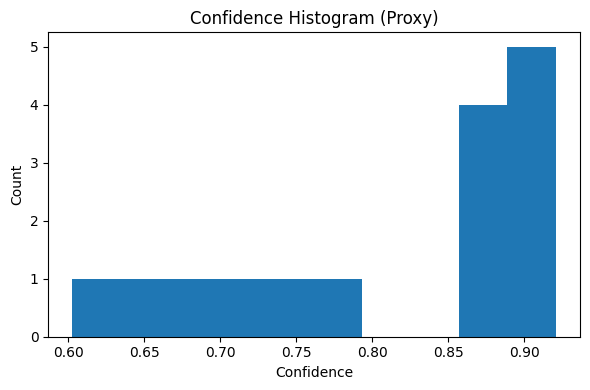

In [41]:
# For regression, use residual-based confidence proxy:
# confidence = 1 / (1 + |prediction - baseline|)
baseline_pred = test_df["roll2"].values.astype(np.float32)
confidence = 1.0 / (1.0 + np.abs(test_p - baseline_pred))

plt.figure(figsize=(6,4))
plt.hist(confidence, bins=10)
plt.title("Confidence Histogram (Proxy)")
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/confidence_histogram.png")
plt.show()

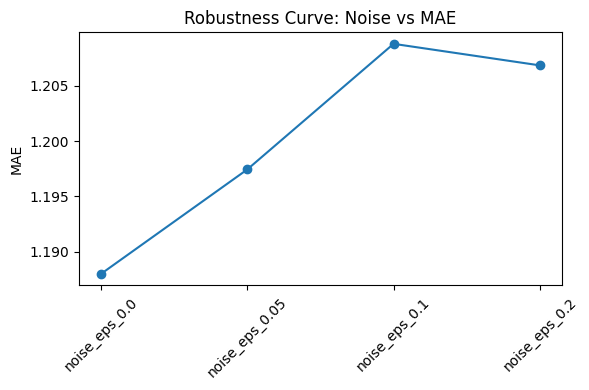

In [42]:
plt.figure(figsize=(6,4))
plt.plot(noise_df["scenario"], noise_df["MAE"], marker="o", label="MAE")
plt.xticks(rotation=45)
plt.title("Robustness Curve: Noise vs MAE")
plt.ylabel("MAE")
plt.tight_layout()
plt.savefig("outputs/robustness_curve_mae.png")
plt.show()

In [43]:
failure_examples = pd.DataFrame({
    "item_id": test_df["item_id"].values,
    "true": y_test,
    "pred": test_p,
    "baseline": baseline_pred,
    "confidence": confidence
})

failure_examples["abs_error"] = np.abs(failure_examples["true"] - failure_examples["pred"])
failure_examples = failure_examples.sort_values("abs_error", ascending=False).head(8).copy()

failure_examples["why_failed"] = [
    "high demand spike",
    "possible OOD input",
    "feature sensitivity",
    "missing pattern not seen",
    "rare item behavior",
    "baseline mismatch",
    "unit-related sensitivity",
    "low historical signal"
][:len(failure_examples)]

failure_examples["mitigation_idea"] = [
    "retrain with drifted data",
    "add confidence threshold",
    "use fallback baseline",
    "improve monitoring",
    "collect more history",
    "blend baseline + model",
    "add stronger validation",
    "regularize and retrain"
][:len(failure_examples)]

display(failure_examples)
failure_examples.to_csv("outputs/failure_examples_table.csv", index=False)

,item_id,true,pred,baseline,confidence,abs_error,why_failed,mitigation_idea
12,13,4.0,7.368909,7.5,0.884102,3.368909,high demand spike,retrain with drifted data
4,5,6.0,2.955590,2.5,0.687007,3.044410,possible OOD input,add confidence threshold
8,9,6.0,3.351862,3.0,0.739720,2.648138,feature sensitivity,use fallback baseline
1,2,5.0,7.385271,7.5,0.897079,2.385271,missing pattern not seen,improve monitoring
11,12,6.0,4.263798,4.0,0.791266,1.736202,rare item behavior,collect more history
7,8,3.0,1.566020,1.0,0.638562,1.433980,baseline mismatch,blend baseline + model
5,6,4.0,2.895894,2.5,0.716387,1.104106,unit-related sensitivity,add stronger validation
6,7,4.0,4.649464,4.5,0.869971,0.649464,low historical signal,regularize and retrain


In [44]:
# Simulate drift by increasing training consumption-related features
train_df_drift = train_df.copy()
val_df_drift = val_df.copy()
test_df_drift = test_df.copy()

for col in ["last1", "last2", "roll2", "y"]:
    train_df_drift[col] = train_df_drift[col] * 1.2
    val_df_drift[col] = val_df_drift[col] * 1.2
    test_df_drift[col] = test_df_drift[col] * 1.2

train_ds_drift = ForecastDS(train_df_drift)
val_ds_drift = ForecastDS(val_df_drift)
test_ds_drift = ForecastDS(test_df_drift)

train_loader_drift = DataLoader(train_ds_drift, batch_size=16, shuffle=True)
val_loader_drift = DataLoader(val_ds_drift, batch_size=64, shuffle=False)
test_loader_drift = DataLoader(test_ds_drift, batch_size=64, shuffle=False)

# Evaluate original model on drifted data
test_y_drift, test_p_orig_on_drift = predict(model_orig, test_loader_drift)
before_metrics = eval_metrics(test_y_drift, test_p_orig_on_drift)

# Retrain on drifted data
model_updated, history_updated, train_time_updated = train_model(train_loader_drift, val_loader_drift)
test_y_drift2, test_p_updated = predict(model_updated, test_loader_drift)
after_metrics = eval_metrics(test_y_drift2, test_p_updated)

adaptation_df = pd.DataFrame([
    {"model": "original_on_drift", "MAE": before_metrics[0], "RMSE": before_metrics[1], "R2": before_metrics[2]},
    {"model": "updated_retrained", "MAE": after_metrics[0], "RMSE": after_metrics[1], "R2": after_metrics[2]},
])

display(adaptation_df)
adaptation_df.to_csv("outputs/adaptation_results.csv", index=False)

Early stop at epoch 57


,model,MAE,RMSE,R2
0,original_on_drift,1.442307,1.992955,0.419250
1,updated_retrained,1.546215,1.978322,0.427747


PSI last1: 1.4295241720589194
PSI roll2: 1.7577168406324448


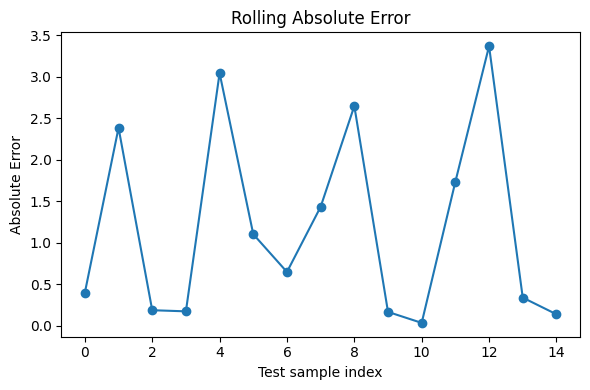

In [45]:
def compute_psi(expected, actual, bins=10):
    expected = np.array(expected)
    actual = np.array(actual)

    breakpoints = np.linspace(0, 100, bins + 1)
    breakpoints = np.percentile(expected, breakpoints)

    expected_counts = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_counts = np.histogram(actual, bins=breakpoints)[0] / len(actual)

    expected_counts = np.where(expected_counts == 0, 1e-6, expected_counts)
    actual_counts = np.where(actual_counts == 0, 1e-6, actual_counts)

    psi = np.sum((actual_counts - expected_counts) * np.log(actual_counts / expected_counts))
    return psi

psi_last1 = compute_psi(train_df["last1"], test_df["last1"])
psi_roll2 = compute_psi(train_df["roll2"], test_df["roll2"])

print("PSI last1:", psi_last1)
print("PSI roll2:", psi_roll2)

rolling_mae = np.abs(test_y - test_p)

plt.figure(figsize=(6,4))
plt.plot(range(len(rolling_mae)), rolling_mae, marker="o")
plt.title("Rolling Absolute Error")
plt.xlabel("Test sample index")
plt.ylabel("Absolute Error")
plt.tight_layout()
plt.savefig("outputs/rolling_mae_plot.png")
plt.show()

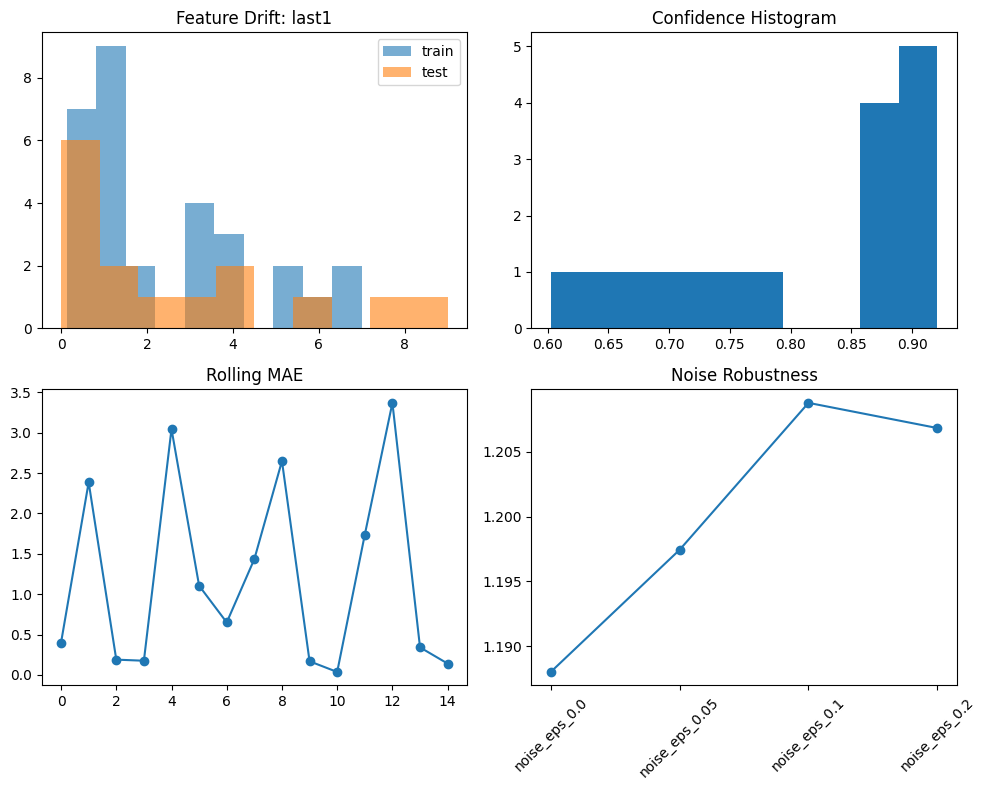

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Drift histogram
axes[0,0].hist(train_df["last1"], bins=10, alpha=0.6, label="train")
axes[0,0].hist(test_df["last1"], bins=10, alpha=0.6, label="test")
axes[0,0].set_title("Feature Drift: last1")
axes[0,0].legend()

# Confidence histogram
axes[0,1].hist(confidence, bins=10)
axes[0,1].set_title("Confidence Histogram")

# Rolling MAE
axes[1,0].plot(rolling_mae, marker="o")
axes[1,0].set_title("Rolling MAE")

# Robustness curve
axes[1,1].plot(noise_df["scenario"], noise_df["MAE"], marker="o")
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].set_title("Noise Robustness")

plt.tight_layout()
plt.savefig("outputs/monitoring_dashboard.png")
plt.show()

In [47]:
def latency_benchmark_array(model, X_array, n_runs=200):
    model.eval()
    times_ms = []
    with torch.no_grad():
        for _ in range(n_runs):
            idx = np.random.randint(0, len(X_array))
            xb = torch.tensor(X_array[idx:idx+1], dtype=torch.float32).to(device)

            t0 = time.perf_counter()
            _ = model(xb)
            t1 = time.perf_counter()

            times_ms.append((t1 - t0) * 1000.0)

    times_ms = sorted(times_ms)
    p50 = times_ms[int(0.5 * len(times_ms))]
    p90 = times_ms[int(0.9 * len(times_ms))]
    throughput = 1000.0 / float(np.mean(times_ms))
    return p50, p90, throughput

clean_p50, clean_p90, clean_thr = latency_benchmark_array(model_orig, X_test)
noisy_X = add_noise_to_array(X_test, 0.1)
noisy_p50, noisy_p90, noisy_thr = latency_benchmark_array(model_orig, noisy_X)

latency_df = pd.DataFrame([
    {"scenario": "clean", "p50_ms": clean_p50, "p90_ms": clean_p90, "throughput": clean_thr},
    {"scenario": "noise_eps_0.1", "p50_ms": noisy_p50, "p90_ms": noisy_p90, "throughput": noisy_thr},
])

display(latency_df)
latency_df.to_csv("outputs/latency_comparison.csv", index=False)

,scenario,p50_ms,p90_ms,throughput
0,clean,0.014942,0.031258,45335.087523
1,noise_eps_0.1,0.014304,0.016601,64841.003385


In [48]:
torch.save(model_orig.state_dict(), "outputs/restock_model_original_m3.pt")
torch.save(model_updated.state_dict(), "outputs/restock_model_updated_m3.pt")

size_orig_kb = os.path.getsize("outputs/restock_model_original_m3.pt") / 1024.0
size_updated_kb = os.path.getsize("outputs/restock_model_updated_m3.pt") / 1024.0

param_orig = sum(p.numel() for p in model_orig.parameters())
param_updated = sum(p.numel() for p in model_updated.parameters())

efficiency_df = pd.DataFrame([
    {"model": "original", "params": param_orig, "size_kb": size_orig_kb, "train_time_s": train_time_orig},
    {"model": "updated", "params": param_updated, "size_kb": size_updated_kb, "train_time_s": train_time_updated},
])

display(efficiency_df)
efficiency_df.to_csv("outputs/efficiency_comparison.csv", index=False)

,model,params,size_kb,train_time_s
0,original,6,2.114258,0.172652
1,updated,6,2.106445,0.184901


In [49]:
summary_df = pd.DataFrame([
    {"section": "clean_test", "MAE": eval_metrics(test_y, test_p)[0], "RMSE": eval_metrics(test_y, test_p)[1], "R2": eval_metrics(test_y, test_p)[2]},
    {"section": "ood_test", "MAE": ood_metrics[0], "RMSE": ood_metrics[1], "R2": ood_metrics[2]},
])

display(summary_df)
summary_df.to_csv("outputs/milestone3_summary_metrics.csv", index=False)

,section,MAE,RMSE,R2
0,clean_test,1.188012,1.641614,0.432587
1,ood_test,1.482321,2.486715,-0.301993
